(Created 7/10/23)
This is adaped from my Grace_BSRI code but uses the airmass to create areas of just venus. 
-Spacial Spectra (individual pixels)
-Cross-section load in

See the old code for previous area selection.

# Import

In [1]:
import numpy as np
import matplotlib
from matplotlib import rc
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy
import scipy.io as sio
from scipy.io import readsav

#below are ones that I added
import pandas as pd
from bokeh.io import push_notebook, show, output_notebook
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, Label, LabelSet,BoxAnnotation
output_notebook()


#Global Variables (This is bad, do not emulate my bad programming)
NORMALIZATION_INDEX = 800 #420 #I dunno pick one

Loading BokehJS ...

In [2]:
region_1a = readsav('venus_1118_total_ortho_30jun21.sav') #night 1
region_2a = readsav('venus_1198_total_ortho_30jun21.sav') #night 1
region_1b = readsav('venus_1118_total_ortho_32jun21.sav') #night 2
region_2b = readsav('venus_1198_total_ortho_32jun21.sav') #night 2

In [3]:
#Print the wavenumber ranges
print("Region 1 Night 1:")
print(str(region_1a['wavenumber'][0]) + ' - ' + str(region_1a['wavenumber'][-1]))
print("Region 1 Night 2:")
print(str(region_1b['wavenumber'][0]) + ' - ' + str(region_1b['wavenumber'][-1]))

print("Region 2 Night 1:")
print(str(region_2a['wavenumber'][0]) + ' - ' + str(region_2a['wavenumber'][-1]))
print("Region 2 Night 2:")
print(str(region_2b['wavenumber'][0]) + ' - ' + str(region_2b['wavenumber'][-1]))

Region 1 Night 1:
1114.7114576040406 - 1122.9214809483474
Region 1 Night 2:
1115.4770923657948 - 1123.696475590839
Region 2 Night 1:
1193.5328127792955 - 1199.8271367294074
Region 2 Night 2:
1193.5986894273308 - 1199.8973422398797


In [4]:
#Figure out what we got
print(region_1a.keys())
print(region_1a.mapgrid)
#print(region_1a.airmass[20,20])

dict_keys(['spec_cube', 'sky', 'wavenumber', 'hdr', 'latitude', 'longitude', 'airmass', 'vel_map', 'mapgrid', 'inttime', 'map_pixel_scale', 'contmap', 'emismap'])
[-20. -19. -18. -17. -16. -15. -14. -13. -12. -11. -10.  -9.  -8.  -7.
  -6.  -5.  -4.  -3.  -2.  -1.   0.   1.   2.   3.   4.   5.   6.   7.
   8.   9.  10.  11.  12.  13.  14.  15.  16.  17.  18.  19.  20.]


Naming Legend:

numbers are wavelength regions, letters are nights

1 = Region 1

2 = Region 2


a = Night 1

b = Night 2


In [5]:
#Find the pixel with the highest integration time? 

#night 1
size_x1a, size_y1a, size_lambda1a = np.shape(region_1a['spec_cube'])
size_x2a, size_y2a, size_lambda2a = np.shape(region_2a['spec_cube'])

#night 2
size_x1b, size_y1b, size_lambda1b = np.shape(region_1b['spec_cube'])
size_x2b, size_y2b, size_lambda2b = np.shape(region_2b['spec_cube'])

#Night 1
highest_integration_1a = 0
best_x1a,best_y1a = 0,0
highest_integration_2a = 0
best_x2a,best_y2a = 0,0

#Night 2
highest_integration_1b = 0
best_x1b,best_y1b = 0,0
highest_integration_2b = 0
best_x2b,best_y2b = 0,0

#Night 1 region 1
for i in range(size_x1a):
    for j in range(size_y1a):
        for k in range(size_lambda1a):
            if region_1a['inttime'][i,j,k] > highest_integration_1a:
                highest_integration_1a = region_1a['inttime'][i,j,k]
                best_x1a = i
                best_y1a = j
                
#Night 2 region 1
for i in range(size_x1b):
    for j in range(size_y1b):
        for k in range(size_lambda1b):
            if region_1b['inttime'][i,j,k] > highest_integration_1b:
                highest_integration_1b = region_1b['inttime'][i,j,k]
                best_x1b = i
                best_y1b = j

                
#Night 1 region 2                
for i in range(size_x2a):
    for j in range(size_y2a):
        for k in range(size_lambda2a):
            if region_2a['inttime'][i,j,k] > highest_integration_2a:
                highest_integration_2a = region_2a['inttime'][i,j,k]
                best_x2a = i
                best_y2a = j


#Night 2 region 2                
for i in range(size_x2b):
    for j in range(size_y2b):
        for k in range(size_lambda2b):
            if region_2b['inttime'][i,j,k] > highest_integration_2b:
                highest_integration_2b = region_2b['inttime'][i,j,k]
                best_x2b = i
                best_y2b = j
                
print("Indices with highest exposure time Night 1:")
print(best_x1a,best_y1a)
print(best_x2a,best_y2a)

print("Indices with highest exposure time Night 2:")
print(best_x1b,best_y1b)
print(best_x2b,best_y2b)


#For now just pick 20,20, since we sum up over all the bright stuff later anyways
#night 1
best_x1a=20
best_y1a=20
best_x2a= 20
best_y2a=20

#For now pick 40,40 because it is approx the center of Venus for Night 2
#night 2
best_x1b=40
best_y1b=40
best_x2b=40
best_y2b=40

Indices with highest exposure time Night 1:
21 16
23 14
Indices with highest exposure time Night 2:
43 55
45 35


In [6]:
##########Get Doppler Shift Numbers

#Night 1
v_venus_e=8.67504477 #ephemeris
v_venus_h=-8.73618 #header
c=3*(10**5)
sky_lambda=1120.7631

del_lambda_e=(v_venus_e/c)*sky_lambda
del_lambda_h=(v_venus_h/c)*sky_lambda
print('ephemeris', del_lambda_e)
print('header', del_lambda_h)

#Night 2
v_venus_e=8.8421249
v_venus_h=-8.925496
c=3*(10**5)
sky_lambda=1120.7631

del_lambda_e=(v_venus_e/c)*sky_lambda
del_lambda_h=(v_venus_h/c)*sky_lambda
print('emphemeris', del_lambda_e)
print('header', del_lambda_h)

ephemeris 0.03240890023021328
header -0.03263729392985999
emphemeris 0.033033091045037294
header -0.033344555219992


# Global Spectra

## Variables

In [7]:
disk1a=np.argwhere(region_1a.airmass>0)
disk1b=np.argwhere(region_1b.airmass>0)

In [8]:
#trying to just get the disk spectra
global_lambda1a = []
global_flux1a = []
for i in range(len(region_1a['wavenumber'])):
    global_lambda1a.append(region_1a['wavenumber'][i])
    the_sum1a=0
    for j in range(len(disk1a)): #disk[j,0]:
        row=disk1a[j,0]
        col=disk1a[j,1]
        the_sum1a = the_sum1a + region_1a['spec_cube'][int(row),int(col),int(i)]
    global_flux1a.append(the_sum1a)

sky_global_lambda1a = []
sky_global_flux1a = []

for i in range(len(region_1a['wavenumber'])):
    sky_global_lambda1a.append(region_1a['wavenumber'][i])
    the_sum1a=0
    for j in range(len(disk1a)): #disk[j,0]:
        row=disk1a[j,0]
        col=disk1a[j,1]
        the_sum1a = the_sum1a + region_1a['sky'][int(row),int(col),int(i)]
    sky_global_flux1a.append(the_sum1a)

    
global_lambda1a_ds=[]
for number in global_lambda1a:
    global_lambda1a_ds.append(number+0.03) #Plus the Doppler Shift

sky_global_lambda1a_ds=[]
for number in sky_global_lambda1a:
    sky_global_lambda1a_ds.append(number+0.03)

#trying to just get the disk spectra
global_lambda1b = []
global_flux1b = []
for i in range(len(region_1b['wavenumber'])):
    global_lambda1b.append(region_1b['wavenumber'][i])
    the_sum1b=0
    for j in range(len(disk1b)): #disk[j,0]:
        row=disk1b[j,0]
        col=disk1b[j,1]
        the_sum1b = the_sum1b + region_1b['spec_cube'][int(row),int(col),int(i)]
    global_flux1b.append(the_sum1b)

sky_global_lambda1b = []
sky_global_flux1b = []

for i in range(len(region_1b['wavenumber'])):
    sky_global_lambda1b.append(region_1b['wavenumber'][i])
    the_sum1b=0
    for j in range(len(disk1b)): #disk[j,0]:
        row=disk1b[j,0]
        col=disk1b[j,1]
        the_sum1b = the_sum1b + region_1b['sky'][int(row),int(col),int(i)]
    sky_global_flux1b.append(the_sum1b)

    
global_lambda1b_ds=[]
for number in global_lambda1b:
    global_lambda1b_ds.append(number+0.03) #Plus the Doppler Shift

sky_global_lambda1b_ds=[]
for number in sky_global_lambda1b:
    sky_global_lambda1b_ds.append(number+0.03)


In [9]:
#THIS HAS NOT BEEN FIXED YET!!!!!! THIS IS STILL OLD VERSION!!!!

#REGION 2

#Create Globally Averaged Spectra:
global_lambda2a = []
global_flux2a = []
for i in range(len(region_2a['wavenumber'])):
    global_lambda2a.append(region_2a['wavenumber'][i])
    the_sum2a=0
    for j in np.linspace(best_x2a-5,best_x2a+5,num=11):
        for k in np.linspace(best_y2a-5,best_y2a+5,num=15):
            the_sum2a = the_sum2a + region_2a['spec_cube'][int(j),int(k),int(i)]
    global_flux2a.append(the_sum2a)
    
global_lambda2b = []
global_flux2b = []
for i in range(len(region_2b['wavenumber'])):
    global_lambda2b.append(region_2b['wavenumber'][i])
    the_sum2b=0
    for j in np.linspace(best_x2b-7,best_x2b+7,num=11):
        for k in np.linspace(best_y2b-7,best_y2b+7,num=15):
            the_sum2b = the_sum2b + region_2b['spec_cube'][int(j),int(k),int(i)]
    global_flux2b.append(the_sum2b)
    
#Create Globally Averaged Sky:
#Night 1
sky_global_lambda2a = []
sky_global_flux2a = []
for i in range(len(region_2a['wavenumber'])):
    sky_global_lambda2a.append(region_2a['wavenumber'][i])
    the_sum2a=0
    for j in np.linspace(best_x2a-5,best_x2a+5,num=11):
        for k in np.linspace(best_y2a-5,best_y2a+5,num=15):
            the_sum2a = the_sum2a + region_2a['sky'][int(j),int(k),int(i)]
    sky_global_flux2a.append(the_sum2a)
    
#Night 2
sky_global_lambda2b = []
sky_global_flux2b = []
for i in range(len(region_2b['wavenumber'])):
    sky_global_lambda2b.append(region_2b['wavenumber'][i])
    the_sum2b=0
    for j in np.linspace(best_x2b-7,best_x2b+7,num=11):
        for k in np.linspace(best_y2b-7,best_y2b+7,num=15):
            the_sum2b = the_sum2b + region_2b['sky'][int(j),int(k),int(i)]
    sky_global_flux2b.append(the_sum2b)
    
#dopler shift:
#Night 1
global_lambda2a_ds=[]
for number in global_lambda2a:
    global_lambda2a_ds.append(number+0.03) #Plus the Doppler Shift

sky_global_lambda2a_ds=[]
for number in sky_global_lambda2a:
    sky_global_lambda2a_ds.append(number+0.03)

#Night 2
global_lambda2b_ds=[]
for number in global_lambda2b:
    global_lambda2b_ds.append(number+0.03)

sky_global_lambda2b_ds=[]
for number in sky_global_lambda2b:
    sky_global_lambda2b_ds.append(number+0.03)


## Data Load In

### Line-by-line Load-in

In [10]:
#import line by line (assuming gathered from HITRAN)
df=pd.read_fwf('/Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/line_by_lines/SO2_all_iso.txt',header=None) 
wn=df.loc[:,1]
abund=df.loc[:,2]
split_df=pd.concat([wn,abund],axis=1)
split_array=split_df.to_numpy()
#print(split_array)

#get desired wavenumbers

#Region 1:
mol_lambda1=[]
abund_lambda1=[]
for a in range(0,len(split_array),1):
    #if split_array[a,0] > 1114.7114576040406 and split_array[a,0] < 1123.696475590839:
    if split_array[a,0] > 1115 and split_array[a,0] < 1123:
        if split_array[a,1] > 1e-21: # and split_array[a,1] < 1e-22: #remove the and for the regular limit
            mol_lambda1.append(split_array[a,0]) #get list of wavenumber locations
            abund_lambda1.append(split_array[a,1]) # get corresponding strengths

print(len(mol_lambda1))
range1_array=np.stack((mol_lambda1, abund_lambda1),axis=-1) #make locations and strengths one array
line_locations_region_1 = np.array(mol_lambda1) #make it match previous naming structure

#Region 2:
mol_lambda2=[]
abund_lambda2=[]
for a in range(0,len(split_array),1):
    if split_array[a,0] > 1193.5328127792955 and split_array[a,0] < 1199.8973422398797:
        if split_array[a,1] > 1e-21:
            mol_lambda2.append(split_array[a,0])
            abund_lambda2.append(split_array[a,1])

print(len(mol_lambda2))
range2_array=np.stack((mol_lambda2, abund_lambda2),axis=-1)
line_locations_region_2 = np.array(mol_lambda2)



78
0


Want to plot two molecules? Use the code below

In [11]:
#import line by line (assuming gathered from HITRAN)
df=pd.read_fwf('/Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/line_by_lines/O3_all.txt',header=None) 
wn=df.loc[:,1]
abund=df.loc[:,2]
split_df=pd.concat([wn,abund],axis=1)
split_array=split_df.to_numpy()
#print(split_array)

#get desired wavenumbers

#Region 1:
two_mol_lambda1=[]
two_abund_lambda1=[]
for a in range(0,len(split_array),1):
    #if split_array[a,0] > 1114.7114576040406 and split_array[a,0] < 1123.696475590839:
    if split_array[a,0] > 1115 and split_array[a,0] < 1123:
        if split_array[a,1] > 1e-21: # and split_array[a,1] < 1e-22: #remove the and for the regular limit
            two_mol_lambda1.append(split_array[a,0]) #get list of wavenumber locations
            two_abund_lambda1.append(split_array[a,1]) # get corresponding strengths

print(len(two_mol_lambda1))
two_range1_array=np.stack((two_mol_lambda1, two_abund_lambda1),axis=-1) #make locations and strengths one array
two_line_locations_region_1 = np.array(two_mol_lambda1) #make it match previous naming structure

12


# Plotting (Doppler Shifted)

## Region 1

In [12]:
#Region 1 relative strength bands
lower_range1=0.14
upper_range1=1.17
total_range1=upper_range1-lower_range1
print('total range is', total_range1)
band_width1=(total_range1)/5

b5_1=lower_range1
b4_1=b5_1+band_width1
b3_1=b4_1+band_width1
b2_1=b3_1+band_width1
b1_1=b2_1+band_width1



total range is 1.0299999999999998


When I was identifying the location of the band centers, I also wanted to be able to compare the absorption strengths. It takes the general range and divides it by 5. Otherwise, it is not physically signifigant.  

The below plot should be fully interactive. If you also plot the line-by-line data, hovering over that line should tell you the absorption strength of that line.

In [32]:
#Get ranges for normalization
r1a_range=(np.max(global_flux1a))-(np.min(global_flux1a))
r1a_sky_range=(np.max(sky_global_flux1a))-(np.min(sky_global_flux1a))
print(np.min(global_flux1a))
normalized = -.01+(((global_flux1a-(np.min(global_flux1a)))*(1+.01))/ r1a_range)
print(np.min(normalized))

r1b_range=(np.max(global_flux1b))-(np.min(global_flux1b))
r1b_sky_range=(np.max(sky_global_flux1b))-(np.min(sky_global_flux1b))

-11.378934817388654
-0.01


In [14]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]

q = figure(title="Wavenumber Region 1 Night 1 Doppler Shifted",sizing_mode="stretch_width",
    height=550,tooltips=TOOLTIPS,
    x_axis_label="Wavenumber (cm^(-1))",
    y_axis_label="Intensity")


q.line(global_lambda1a_ds,-.01+(((global_flux1a-(np.min(global_flux1a)))*(1+.01))/ r1a_range),legend_label='Venus N1', color='red') #night 1 venus
#q.line(global_lambda1b_ds,-.01+(((global_flux1b-(np.min(global_flux1b)))*(1+.01))/ r1b_range),legend_label='Venus N2', color='green') #night 2 venus


q.line(sky_global_lambda1a_ds,(sky_global_flux1a-(np.min(sky_global_flux1a)))/ r1a_sky_range,legend_label='Sky N1', color='green') #night 1 sky
#q.line(sky_global_lambda1b_ds,(sky_global_flux1b-(np.min(sky_global_flux1b)))/ r1b_sky_range,legend_label='sky N2', color='blue') #night 2 sky


#for place in range(0,len(line_locations_region_1)):
    #q.line([range1_array[place,0],range1_array[place,0]], [1.06,0.60],color='black',line_width=1,name=str(range1_array[place,1]))
    

    
for place in range(0,len(two_line_locations_region_1)):
    q.line([two_range1_array[place,0],two_range1_array[place,0]], [1.06,0.60],color='black',line_width=1,name=str(two_range1_array[place,1]))
    


#q.line(1116,1,legend_label='O3', color='black',visible=False)
q.line(1116,1,legend_label='O3', color='black',visible=False)

q.legend.location = "bottom_right"

show(q)

## Region 2

In [15]:
#Region 2 relative strength bands
lower_range2=0.32 #y loc of lowest point (band center)
upper_range2=1.07 #y loc of about highest data points
total_range2=upper_range2-lower_range2
print('total range is', total_range2)
band_width2=(total_range2)/5
print('band width is', band_width2)
b5_2=lower_range2
b4_2=b5_2+band_width2
b3_2=b4_2+band_width2
b2_2=b3_2+band_width2
b1_2=b2_2+band_width2


total range is 0.75
band width is 0.15


In [16]:
#Get ranges for normalization
r2a_range=(np.max(global_flux2a))-(np.min(global_flux2a))
r2a_sky_range=(np.max(sky_global_flux2a))-(np.min(sky_global_flux2a))

r2b_range=(np.max(global_flux2b))-(np.min(global_flux2b))
r2b_sky_range=(np.max(sky_global_flux2b))-(np.min(sky_global_flux2b))

In [17]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]

p = figure(title="Wavenumber Region 2 Night 2 Doppler Shifted",sizing_mode="stretch_width",
    height=550,tooltips=TOOLTIPS)


#p.line(global_lambda2a_ds,-.01+(((global_flux2a-(np.min(global_flux2a)))*(1+.01))/ r2a_range),legend_label='Venus N1', color='blue') #night 1 venus
p.line(global_lambda2b_ds,-.01+(((global_flux2b-(np.min(global_flux2b)))*(1+.01))/ r2b_range),legend_label='Venus N2', color='blue') #night 2 venus


#p.line(sky_global_lambda2a_ds,(sky_global_flux2a-(np.min(sky_global_flux2a)))/ r2a_sky_range,legend_label='sky N1', color='green') #night 1 sky
p.line(sky_global_lambda2b_ds,(sky_global_flux2b-(np.min(sky_global_flux2b)))/ r2b_sky_range,legend_label='sky N2', color='green') #night 2 sky

#for place in range(0,len(line_locations_region_2)):
    #p.line([range2_array[place,0],range2_array[place,0]], [1.15,0.8],color='black',line_width=1,name=str(range2_array[place,1]))
#p.add_tools(hover)

p.legend.location = "bottom_right"

show(p)

# Contour Plots

## Region 1

### Night 1

In [18]:
range(size_y1a)

range(0, 41)

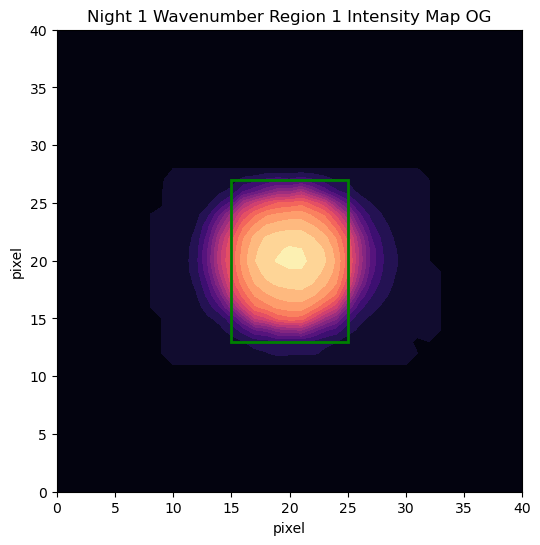

In [19]:
#see contour map of view

z = np.zeros((int(size_y1a), int(size_y1a)))
for i in range(size_x1a):
    for j in range(size_y1a):
        z[i,j] = np.sum(region_1a['spec_cube'][i,j])
        #print(np.sum(region_1['spec_cube'][i,j]))
'''        
z = np.zeros((int(size_y1a), int(size_y1a)))
for i in range(size_y1a):
    for j in range(size_x1a):
        z[i,j] = np.sum(region_1a['spec_cube'][i,j])
        #print(np.sum(region_1['spec_cube'][i,j]))
      
        '''
        
        
        
#print(z)
Figure = plt.figure(figsize=(6,6))
#plt.contour(z, levels=8)
plt.contourf(z, levels=20,cmap='magma')

plt.title('Night 1 Wavenumber Region 1 Intensity Map OG')

plt.xlabel('pixel')
plt.ylabel('pixel')

#add dots where the individual spectra are coming from

#plt.scatter(best_x1a,best_x1a,color='black')
#plt.scatter(best_x1a-4,best_y1a-5,color='green')
#plt.scatter(best_x1a+2,best_y1a+3,color='magenta')


#add dots that mark boundaries for global flux area
#plt.scatter(best_x1a+5,best_y1a+7,color='red')
#plt.scatter(best_x1a-5,best_y1a-7,color='black')

#make rectable of global flux area
left, bottom, width, height = (best_x1a-5, best_y1a-7, (best_x1a+5)-(best_x1a-5), (best_y1a+7)-(best_y1a-7))
rect=patches.Rectangle((left,bottom),width,height, fill=False,color="green",linewidth=2)
                       
plt.gca().add_patch(rect)


#plt.savefig('/Users/gracesanger-johnson/Downloads/Senior_Project/N1_R1_presi_contour_rectangle.png',format='png',bbox_inches='tight')

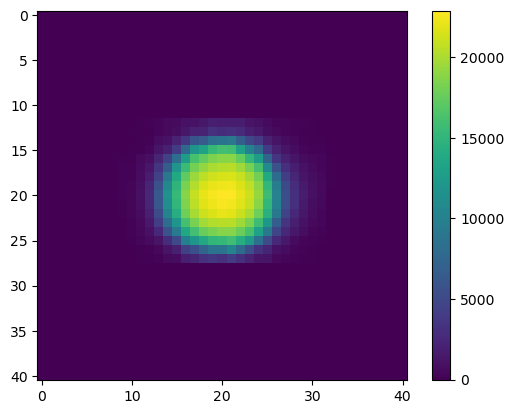

In [20]:
fig=plt.imshow(z)
cb=plt.colorbar(fig)

### Night 2

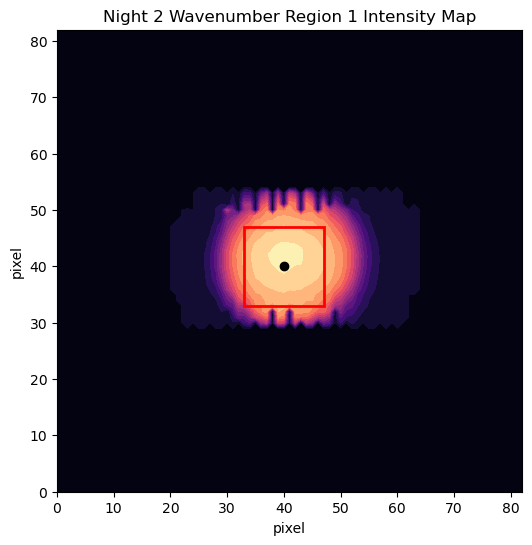

In [21]:
#see contour map of view
z = np.zeros((int(size_y1b), int(size_y1b)))
for i in range(size_x1b):
    for j in range(size_y1b):
        z[i,j] = np.sum(region_1b['spec_cube'][i,j])
        #print(np.sum(region_1['spec_cube'][i,j]))
#print(z)
Figure = plt.figure(figsize=(6,6))
#plt.contour(z, levels=8)

plt.contourf(z, levels=15,cmap='magma')

plt.title('Night 2 Wavenumber Region 1 Intensity Map')
plt.xlabel('pixel')
plt.ylabel('pixel')

#add dots where the individual spectra are coming from
plt.scatter(best_x1b,best_x1b,color='black')
#plt.scatter(best_x1b-2,best_y1b-3,color='blue')
#plt.scatter(best_x1b+2,best_y1b+3,color='green')

#add dots that mark boundaries for global flux area
#plt.scatter(best_x1b+5,best_y1b+7,color='black')
#plt.scatter(best_x1b-5,best_y1b-7,color='black')

#make rectable of global flux area
left, bottom, width, height = (best_x1b-7, best_y1b-7, (best_x1b+7)-(best_x1b-7), (best_y1b+7)-(best_y1b-7))
rect=patches.Rectangle((left,bottom),width,height,
                        fill=False,
                        color="red",
                       linewidth=2)
                       
plt.gca().add_patch(rect)


#plt.savefig('/Users/gracesanger-johnson/Downloads/Senior_Project/Spectra_Pictures/N2_R1_Contour.png',format='png',bbox_inches='tight'
#plt.savefig('/Users/gracesanger-johnson/Downloads/Senior_Project/insert/N2_R1_Contour.png',format='png',bbox_inches='tight')


## Region 2

### Night 1

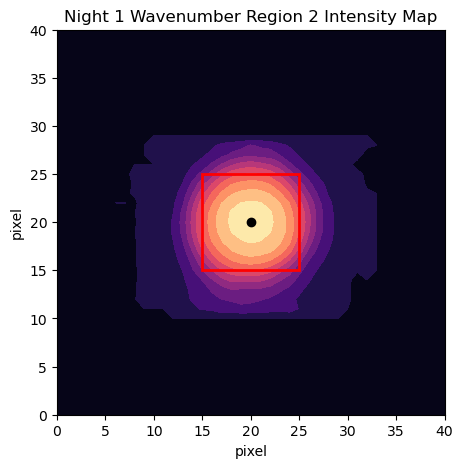

In [22]:
#see contour map of view
z = np.zeros((int(size_y2a), int(size_y2a)))
for i in range(size_x2a):
    for j in range(size_y2a):
        z[i,j] = np.sum(region_2a['spec_cube'][i,j])
        #print(np.sum(region_1['spec_cube'][i,j]))
#print(z)
Figure = plt.figure(figsize=(5,5))
#plt.contour(z, levels=8)

plt.contourf(z, levels=9,cmap='magma')

plt.title('Night 1 Wavenumber Region 2 Intensity Map')
plt.xlabel('pixel')
plt.ylabel('pixel')

#add dots where the individual spectra are coming from
plt.scatter(best_x2a,best_x2a,color='black')
#plt.scatter(best_x2a-2,best_y2a-2,color='orange')
#plt.scatter(best_x2a+2,best_y2a+2,color='red')

#add dots that mark boundaries for global flux area
#plt.scatter(best_x2a+5,best_y2a+5,color='black')
#plt.scatter(best_x2a-5,best_y2a-5,color='black')
left, bottom, width, height = (best_x2a-5, best_y2a-5, (best_x2a+5)-(best_x2a-5), (best_y2a+5)-(best_y2a-5))
rect=patches.Rectangle((left,bottom),width,height, 
                        fill=False,
                        color="red",
                       linewidth=2)
                       
plt.gca().add_patch(rect)

#plt.savefig('/Users/gracesanger-johnson/Downloads/Senior_Project/Spectra_Pictures/N2_R1_Contour.png',format='png',bbox_inches='tight'
#plt.savefig('/Users/gracesanger-johnson/Downloads/Senior_Project/insert/N1_R2_Contour.png',format='png',bbox_inches='tight')



### Night 2

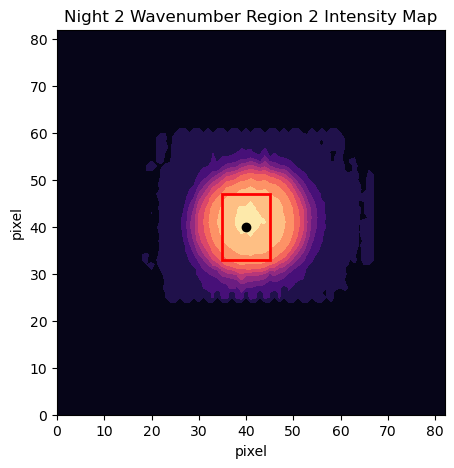

In [23]:
#see contour map of view
z = np.zeros((int(size_y2b), int(size_y2b)))
for i in range(size_x2b):
    for j in range(size_y2b):
        z[i,j] = np.sum(region_2b['spec_cube'][i,j])
        #print(np.sum(region_1['spec_cube'][i,j]))
#print(z)
Figure = plt.figure(figsize=(5,5))
#plt.contour(z, levels=8)

plt.contourf(z, levels=9,cmap='magma')

plt.title('Night 2 Wavenumber Region 2 Intensity Map')
plt.xlabel('pixel')
plt.ylabel('pixel')

#add dots where the individual spectra are coming from
plt.scatter(best_x2b,best_x2b,color='black')
#plt.scatter(best_x2b-2,best_y2b-2,color='orange')
#plt.scatter(best_x2b+2,best_y2b+2,color='red')


#add dots that mark boundaries for global flux area
#lt.scatter(best_x2b+5,best_y2b+7,color='black')
#plt.scatter(best_x2b-5,best_y2b-7,color='black')

left, bottom, width, height = (best_x2b-5, best_y2b-7, (best_x2b+5)-(best_x2b-5), (best_y2b+7)-(best_y2b-7))
rect=patches.Rectangle((left,bottom),width,height, 
                        fill=False,
                        color="red",
                       linewidth=2)
                       
plt.gca().add_patch(rect)

#plt.savefig('/Users/gracesanger-johnson/Downloads/Senior_Project/Spectra_Pictures/N2_R1_Contour.png',format='png',bbox_inches='tight'
#plt.savefig('/Users/gracesanger-johnson/Downloads/Senior_Project/insert/N2_R2_Contour.png',format='png',bbox_inches='tight')


# Spacial Zones

In [24]:
#load function
def spacerange(file,coord,cmin,cmax): 
    
    coord=str(coord)
    
    if coord=='longitude' or coord =='long':
        param='longitude'
    elif coord == 'latitude' or coord=='lat':
        param='latitude'
    else:
        print('Improper parameter given')
    
    manipulate_disk=np.array(file[param])
    if param=='longitude':
        bkg=360
    elif param=='latitude':
        bkg=0
    manipulate_disk[manipulate_disk == int(bkg)] = 1000
    
    i_regionmax=np.argwhere(manipulate_disk>cmin)
    
    i_regionmin=np.argwhere(manipulate_disk<cmax)
    
    small_shape=len(i_regionmax)
    small_arr=i_regionmax
    big_shape=len(i_regionmin)
    big_arr=i_regionmin
    
    if len(i_regionmax) > len(i_regionmin):
        big_shape=len(i_regionmax)
        big_arr=i_regionmax
        small_shape=len(i_regionmin)
        small_arr=i_regionmin
    
    difference=big_shape-small_shape
    good_arr=np.concatenate((small_arr,np.zeros((difference,2))),axis=0)

    
    match=[]
    final_pixels=np.array([])
    for b_loop in range(len(big_arr)):
        for s_loop in range(len(small_arr)):
            if big_arr[b_loop,0]==small_arr[s_loop,0] and big_arr[b_loop,1]==small_arr[s_loop,1]:
                if len(final_pixels) == 0:
                    match_i=np.array(small_arr[s_loop])
                    final_pixels=match_i
                    break
                match=np.array(small_arr[s_loop])
                final_pixels=np.block([[final_pixels],[match]])
    return(final_pixels)

In [25]:
#what data do you want???

disk1a=spacerange(region_1a,'lat',30,60) #night 1
disk1b=spacerange(region_1b,'lat',30,60) #night 2

In [26]:
#get averaged spectra over that area
zonal_lambda1a = []
zonal_flux1a = []
for i in range(len(region_1a['wavenumber'])):
    zonal_lambda1a.append(region_1a['wavenumber'][i])
    the_sum1a=0
    for j in range(len(disk1a)): #disk[j,0]:
        row=disk1a[j,0]
        col=disk1a[j,1]
        the_sum1a = the_sum1a + region_1a['spec_cube'][int(row),int(col),int(i)]
    zonal_flux1a.append(the_sum1a)

sky_zonal_lambda1a = []
sky_zonal_flux1a = []

for i in range(len(region_1a['wavenumber'])):
    sky_zonal_lambda1a.append(region_1a['wavenumber'][i])
    the_sum1a=0
    for j in range(len(disk1a)): #disk[j,0]:
        row=disk1a[j,0]
        col=disk1a[j,1]
        the_sum1a = the_sum1a + region_1a['sky'][int(row),int(col),int(i)]
    sky_zonal_flux1a.append(the_sum1a)

    
zonal_lambda1a_ds=[]
for number in zonal_lambda1a:
    zonal_lambda1a_ds.append(number+0.03) #Plus the Doppler Shift

sky_zonal_lambda1a_ds=[]
for number in sky_zonal_lambda1a:
    sky_zonal_lambda1a_ds.append(number+0.03)

#trying to just get the disk spectra
zonal_lambda1b = []
zonal_flux1b = []
for i in range(len(region_1b['wavenumber'])):
    zonal_lambda1b.append(region_1b['wavenumber'][i])
    the_sum1b=0
    for j in range(len(disk1b)): #disk[j,0]:
        row=disk1b[j,0]
        col=disk1b[j,1]
        the_sum1b = the_sum1b + region_1b['spec_cube'][int(row),int(col),int(i)]
    zonal_flux1b.append(the_sum1b)

sky_zonal_lambda1b = []
sky_zonal_flux1b = []

for i in range(len(region_1b['wavenumber'])):
    sky_zonal_lambda1b.append(region_1b['wavenumber'][i])
    the_sum1b=0
    for j in range(len(disk1b)): #disk[j,0]:
        row=disk1b[j,0]
        col=disk1b[j,1]
        the_sum1b = the_sum1b + region_1b['sky'][int(row),int(col),int(i)]
    sky_zonal_flux1b.append(the_sum1b)

    
zonal_lambda1b_ds=[]
for number in zonal_lambda1b:
    zonal_lambda1b_ds.append(number+0.03) #Plus the Doppler Shift

sky_zonal_lambda1b_ds=[]
for number in sky_zonal_lambda1b:
    sky_zonal_lambda1b_ds.append(number+0.03)


## Plotting

In [27]:
#Get ranges for normalization
r1a_zrange=(np.max(zonal_flux1a))-(np.min(zonal_flux1a))
r1a_sky_zrange=(np.max(sky_zonal_flux1a))-(np.min(sky_zonal_flux1a))

r1b_zrange=(np.max(zonal_flux1b))-(np.min(zonal_flux1b))
r1b_sky_zrange=(np.max(sky_zonal_flux1b))-(np.min(sky_zonal_flux1b))

In [28]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]

q = figure(title="Wavenumber Region 1 Night 1 Zonal (Mid-Lat)",sizing_mode="stretch_width",
    height=550,tooltips=TOOLTIPS)


q.line(zonal_lambda1a_ds,-.01+(((zonal_flux1a-(np.min(zonal_flux1a)))*(1+.01))/ r1a_zrange),legend_label='Venus N1', color='blue') #night 1 venus

#q.line(zonal_lambda1b_ds,-.01+(((zonal_flux1b-(np.min(zonal_flux1b)))*(1+.01))/ r1b_zrange),legend_label='Venus N2', color='red') #night 2 venus


q.line(sky_zonal_lambda1a_ds,(sky_zonal_flux1a-(np.min(sky_zonal_flux1a)))/ r1a_sky_zrange,legend_label='sky N1', color='green') #night 1 sky
#q.line(sky_zonal_lambda1b_ds,(sky_zonal_flux1b-(np.min(sky_zonal_flux1b)))/ r1b_sky_zrange,legend_label='sky N2', color='silver') #night 2 sky


#for place in range(0,len(line_locations_region_1)):
   # q.line([range1_array[place,0],range1_array[place,0]], [1.06,0.60],color='black',line_width=1,name=str(range1_array[place,1]))



#plot global shit:

q.line(global_lambda1a_ds,-.01+(((global_flux1a-(np.min(global_flux1a)))*(1+.01))/ r1a_range),legend_label='Global Venus N1', color='deeppink') #night 1 venus
#q.line(global_lambda1b_ds,-.01+(((global_flux1b-(np.min(global_flux1b)))*(1+.01))/ r1b_range),legend_label='Venus N2', color='red') #night 2 venus


q.line(sky_global_lambda1a_ds,(sky_global_flux1a-(np.min(sky_global_flux1a)))/ r1a_sky_range,legend_label='Global sky N1', color='palegreen') #night 1 sky
#q.line(sky_global_lambda1b_ds,(sky_global_flux1b-(np.min(sky_global_flux1b)))/ r1b_sky_range,legend_label='sky N2', color='silver') #night 2 sky


q.legend.location = "bottom_right"

show(q)